# Feature Engineering — 20 Advanced Behavioral Features

This notebook computes **20 customer-level features** across **5 behavioral families** from the raw dataset and the RFM dataset to help the model work more efficently. 

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from IPython.display import display

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [26]:
import sys
import os

sys.path.append(os.path.abspath('..'))
from config import SEED, CORR_THRESHOLD, FORCE_KEEP, CANDIDATES, FAMILIES, BULK_QTY, B2B_THRESHOLD


print("Successfully loading hyperparams!")

Successfully loading hyperparams!


In [27]:

CLEAN_TRANSACTION_PATH = '../data/processed/cleaned_transactions.csv'
RFM_TABLE_PATH='../data/processed/rfm_summary.csv'
RAW_DATASET_PATH='../data/raw/ecommerce-data.csv'


df = pd.read_csv(CLEAN_TRANSACTION_PATH, encoding='unicode_escape',parse_dates=['InvoiceDate'])
print(f"Cleaned transaction data shape: {df.shape}")
rfm = pd.read_csv(RFM_TABLE_PATH)
print(f"RFM table data shape: {rfm.shape}")
raw = pd.read_csv(RAW_DATASET_PATH, encoding='unicode_escape')
print(f"Raw dataset shape: {raw.shape}")

Cleaned transaction data shape: (354321, 12)
RFM table data shape: (3920, 4)
Raw dataset shape: (541909, 8)


In [28]:
# Cancellation invoices start with 'C'
r = raw[
    (raw['Country'] == 'United Kingdom') &
    raw['CustomerID'].notna()
].copy()

r['is_cancel'] = r['InvoiceNo'].astype(str).str.startswith('C')
r['TotalPrice'] = r['Quantity'] * r['UnitPrice']

df_cancels = r[r['is_cancel']].copy()
df_sales = r[~r['is_cancel'] & (r['Quantity'] > 0)].copy()

print(f"Sales transactions: {df_sales.shape[0]:,}")
print(f"Cancellation transactions: {df_cancels.shape[0]:,}")
print(f"Customers in sales: {df_sales['CustomerID'].nunique():,}")
print(f"Customers with cancellations: {df_cancels['CustomerID'].nunique():,}")

Sales transactions: 354,345
Cancellation transactions: 7,533
Customers in sales: 3,921
Customers with cancellations: 1,411


In [29]:
# Helper function

# Helper: coefficient of variation (returns 0 if std or mean is 0)
def cv(series):
    """Coefficient of variation, safe for constant series."""
    m = series.mean()
    if m == 0 or len(series) < 2:
        return 0.0
    return series.std() / m

# Helper: Gini coefficient
def gini(v):
    v = np.sort(np.asarray(v, dtype=float))
    n = len(v)
    if n <= 1 or v.sum() == 0:
        return 0.0
    i = np.arange(1, n + 1)
    return float((2 * (i * v).sum() - (n + 1) * v.sum()) / (n * v.sum()))

In [30]:
# Reference date = 1 day after last transaction
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'], errors='coerce')

reference_date = df_sales['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date}")

# Build per-order summaries first (for order-level features)
order_summary = df_sales.groupby(['CustomerID', 'InvoiceNo']).agg(
    order_date=('InvoiceDate', 'min'),
    order_total=('TotalPrice', 'sum'),
    line_count=('StockCode', 'count'),
    total_qty=('Quantity', 'sum'),
    unique_skus=('StockCode', 'nunique'),
).reset_index().sort_values(['CustomerID', 'order_date'])

print(f"Order summary: {order_summary.shape[0]:,} orders")

customer_summary = order_summary.groupby('CustomerID')
display(customer_summary.head())

Reference date: 2011-12-10 12:49:00
Order summary: 16,649 orders


,CustomerID,InvoiceNo,order_date,order_total,line_count,total_qty,unique_skus
0,12346.0,541431,2011-01-18 10:01:00,77183.60,1,74215,1
1,12747.0,537215,2010-12-05 15:38:00,358.56,7,108,7
2,12747.0,538537,2010-12-13 10:41:00,347.71,8,105,8
3,12747.0,541677,2011-01-20 14:01:00,303.04,5,88,5
4,12747.0,545321,2011-03-01 14:53:00,310.78,12,146,12
...,...,...,...,...,...,...,...
16633,18283.0,550957,2011-04-21 16:37:00,117.68,56,87,55
16634,18283.0,554157,2011-05-23 11:33:00,99.47,44,62,32
16646,18287.0,554065,2011-05-22 10:39:00,765.28,29,488,27
16647,18287.0,570715,2011-10-12 10:23:00,1001.32,38,990,38


### 1. Feature Family: Purchase Rhythm

**Objective:** This feature group goes beyond merely counting transactions. It evaluates the **rhythm**, **stability**, and **churn risk** of each customer. These features effectively address the inherent blind spots of the traditional Recency and Frequency metrics in the standard RFM model.

**Feature Details:**

* **`Recency`:** The number of days from the customer's last purchase to the dataset's snapshot date.
  * *Business Value:* Differentiates currently active customers from those who have likely churned.
* **`ActiveSpanDays` (Customer Lifespan):** The number of days between the customer's first and last invoice.
  * *Business Value:* Assesses the reliability of the customer's purchasing history (e.g., distinguishing a long-term loyal customer from a short-term/one-off buyer).
* **`MonthlyOrderRate`:** Total number of orders / (ActiveSpanDays / 30).
  * *Business Value:* Reflects the true purchasing frequency. It fixes a major RFM flaw by creating a fair comparison between newly acquired customers (low total orders but high purchasing rhythm) and veteran customers (high total orders but low rhythm).
* **`InterPurchaseCV` (Purchase Gap Variation):** The Coefficient of Variation (Standard Deviation / Mean) of the days between consecutive purchases.
  * *Business Value:* Measures purchasing "consistency". A $CV \approx 0$ indicates a highly stable, habitual buyer (perfect targets for Subscription models). A high $CV$ reveals impulsive, erratic, or seasonal buying behaviors (ideal targets for Flash Sales).




$$ \text{Recency} = (\text{reference date} - \text{last buying date}).\text{days} $$
$$ \text{InterPurchaseCV} = \frac{\sigma}{\mu} \text{ of the difference between buying dates} $$
$$ \text{ActiveSpanDays} = \text{first buying date} - \text{last buying date} $$
$$ \text{MonthlyOrderRate} = \frac{\text{number of invoice}}{\max(\text{ActiveSpanDays}/30,\ 1)} $$

In [31]:
# FAMILY 1: Purchase Rhythm
def purchase_rhythm_features(group):
    """Compute Recency, InterPurchaseCV, ActiveSpanDays, MonthlyOrderRate,RecencyAnomaly."""
    dates = group['order_date'].sort_values()
    n_orders = len(dates)
    last_date = dates.iloc[-1]
    first_date = dates.iloc[0]

    recency = (reference_date - last_date).days
    active_span = (last_date - first_date).days

    if n_orders < 2:
        inter_cv = 0.0
        monthly_rate = float(n_orders)  # treat as 1 month
    else:
        gaps = dates.diff().dt.days
        inter_cv = cv(gaps)
        months = max(active_span / 30, 1.0)
        monthly_rate = n_orders / months
        mean_gap = gaps.mean()

    return pd.Series({
        'Recency': recency,
        'InterPurchaseCV': inter_cv,
        'ActiveSpanDays': active_span,
        'MonthlyOrderRate': monthly_rate,
    })

print("Computing Purchase Rhythm features...")
f_rhythm = order_summary.groupby('CustomerID').apply(
    purchase_rhythm_features, include_groups=False
)

display(f_rhythm.head())

Computing Purchase Rhythm features...


,Recency,InterPurchaseCV,ActiveSpanDays,MonthlyOrderRate
CustomerID,,,,
12346.0,326.0,0.000000,0.0,1.000000
12747.0,2.0,0.481030,366.0,0.901639
12748.0,1.0,2.194849,372.0,16.935484
12749.0,4.0,0.984354,209.0,0.717703
12820.0,3.0,1.160315,323.0,0.371517


### 2. Feature Family: Spend Shape

**Objective:** This feature group addresses the primary blind spot of the Monetary (M) metric in traditional RFM. Two customers might both spend $1,000, but one makes ten $100 purchases while the other makes a single $1,000 purchase. These features help the model understand a customer's budget allocation, price sensitivity, and spending momentum over time.

**Feature Details:**

* **`AOV` (Average Order Value):** Total revenue divided by the total number of orders.
  * *Business Value:* Separates premium shoppers (high-value baskets) from budget-conscious/frequent shoppers (small, incremental baskets). This is crucial for determining free shipping thresholds or targeted discount tiers.
* **`SpendGini` (Spend Gini Coefficient):** Measures the inequality among a single customer's invoice values (0 = all invoices have the exact same value; approaching 1.0 = spending is heavily skewed toward one massive invoice).
  * *Business Value:* Flags "artificial VIPs". A customer with a high Monetary value but a high SpendGini (e.g., 0.9) likely just made one huge bulk or event-driven purchase. They shouldn't be treated as consistent, high-value loyalists.
* **`PriceCV` (Price Coefficient of Variation):** The Coefficient of Variation of the unit prices of items the customer has purchased.
  * *Business Value:* Measures "price sensitivity" and basket diversity. A low PriceCV means the customer strictly sticks to a specific price tier. A high PriceCV indicates a versatile shopper willing to buy across all price points (from $1 knick-knacks to $100 premium items).
* **`MaxSpendShare`:** The revenue from the customer's largest single invoice divided by their total spend (Monetary).
  * *Business Value:* Highly correlated with SpendGini but more straightforward. K-Means uses this to identify customers whose lifetime value is heavily anchored by a single transaction, preventing marketing from misallocating VIP retention budgets on "one-hit wonders."
* **`SpendAcceleration`:** The slope (trendline) of the customer's order values over time.
  * *Business Value:* Captures "spending momentum". A positive slope (+) means the customer is spending progressively more with each subsequent order (prime targets for up-selling). A negative slope (-) indicates shrinking basket sizes, serving as a strong early warning sign of waning interest or potential churn.

$$ \text{AOV} = \frac{\text{tổng chi tiêu}}{\text{số hoá đơn}} $$
$$\qquad \text{PriceCV} = \frac{\sigma(\text{UnitPrice})}{\mu(\text{UnitPrice})} $$
$$ \text{SpendGini} = \frac{\sum_{i=1}^{n}(2i - n - 1)\,s_{(i)}}{n \sum_{i=1}^{n} s_{(i)}}
\quad \text{with } s_{(1)} \le \dots \le s_{(n)} \text{ is the spending for each sorted invoice} $$
$$ \text{MaxSpendShare} = \frac{\max(\text{spending for invoices})}{\text{total spending}} $$
$$ \text{SpendAcceleration} = \operatorname{clip}\!\left(
\frac{\overline{S}_{\text{first quarter}} - \overline{S}_{\text{last quarter}}}
{|\overline{S}_{\text{first quarter}}|},\ -3,\ 3\right) $$


In [32]:
# FAMILY 2: Spend Shape
def spend_shape_features(group):
    """Compute AOV, SpendGini, PriceCV, MaxSpendShare, SpendAcceleration."""
    totals = group['order_total'].values
    n_orders = len(totals)
    total_spend = totals.sum()
    n_items= group['total_qty'].values.sum()

    aov = total_spend / n_orders if n_orders > 0 else 0.0
    spend_gini = gini(totals)
    max_spend_share = totals.max() / total_spend if total_spend > 0 else 1.0

    return pd.Series({
        'AOV': aov,
        'SpendGini': spend_gini,
        'MaxSpendShare': max_spend_share,
    })

f_spend = order_summary.groupby('CustomerID').apply(
    spend_shape_features, include_groups=False
)

# 2. PriceCV: Computed from line-item level (df_sales)
p = df_sales.groupby('CustomerID')['UnitPrice'].agg(['mean', 'std'])
price_cv = (p['std'] / p['mean']).fillna(0.0).rename('PriceCV')

# 3. SpendAcceleration: Computed from monthly aggregated totals (df_sales)
month = (df_sales.assign(YM=df_sales['InvoiceDate'].dt.to_period('M'))
         .groupby(['CustomerID', 'YM'])['TotalPrice'].sum()
         .reset_index(name='ms'))

def _accel(grp):
    s = grp.sort_values('YM')['ms'].values
    if len(s) < 3:                       # Under 3 months cannot tell any trends
        return 0.0
    first, last = s[:3].mean(), s[-3:].mean()
    return float(np.clip((last - first) / (abs(first) + 1e-9), -3.0, 3.0))

spend_accel = month.groupby('CustomerID').apply(
    _accel, include_groups=False
).rename('SpendAcceleration')

# 4. Join everything together
f_spend = f_spend.join(price_cv).join(spend_accel)

display(f_spend.head())

,AOV,SpendGini,MaxSpendShare,PriceCV,SpendAcceleration
CustomerID,,,,,
12346.0,77183.600000,0.000000,1.000000,0.000000,0.000000
12747.0,381.455455,0.128633,0.160958,0.759477,0.080691
12748.0,160.570143,0.621603,0.060104,5.297775,1.780151
12749.0,818.176000,0.387200,0.456242,0.948402,-0.028860
12820.0,235.585000,0.139896,0.364794,0.694878,0.054495


### 3. Feature Family: Basket Behavior

**Objective:** This feature group looks past the monetary value and timestamps to examine the structural composition of the shopping cart. It reveals customer habits regarding product exploration, brand loyalty at the item level, and predictability of basket sizes.

**Feature Details:**

* **`RepeatSKUFraction`:** The ratio of previously purchased items (SKUs) to the total items in a customer's history.
  * *Business Value:* Identifies "habitual buyers" who repeatedly purchase the same consumables. High values indicate strong brand/item loyalty, making them perfect targets for automated replenishment reminders.
* **`NewSKURate`:** The propensity of a customer to add never-before-bought items to their cart.
  * *Business Value:* Measures receptiveness to product discovery. Customers with a high rate are highly explorative and are the ideal segment for cross-selling algorithms and new product launch campaigns.
* **`BasketSizeCV` (Basket Size Variation):** The Coefficient of Variation (Std / Mean) of the number of unique items across the customer's orders.
  * *Business Value:* Measures volumetric stability. A low CV means highly predictable, stable basket sizes (grocery-shopping style). A high CV flags erratic shopping behavior, often driven by external triggers like seasonal mega-sales.


$$ \text{RepeatSKUFraction} = \frac{\#\{\text{SKU appearing at} > 1 \text{ invoice}\}}{\#\{\text{total bought SKU}\}} $$
$$ \text{BasketSizeCV} = \frac{\sigma}{\mu} \text{ of SKU of each invoice} $$
$$ \text{NewSKURate} = \frac{1}{K}\sum_{k=1}^{K}
\frac{|\,S_k \setminus (S_1 \cup \dots \cup S_{k-1})\,|}{|S_k|}
\quad \text{with } S_k \text{ is the set of SKU for each invoice } k \text{ over time} $$

In [33]:
# 3. Feature Family: Basket Behaviour

print("Computing Basket Behavior features (Vectorized Mode)...")

inv_sku = (
    df_sales.groupby(['CustomerID', 'InvoiceNo'])
    .agg(date=('InvoiceDate', 'min'), skus=('StockCode', lambda x: frozenset(x)))
    .reset_index().sort_values(['CustomerID', 'date'])
)

def _new_sku(grp):
    seen, rates = set(), []
    for skus in grp['skus']:
        rates.append(len(skus - seen) / len(skus)) 
        seen.update(skus)
    return float(np.mean(rates)) if rates else 1.0

new_sku_rate = (
    inv_sku.groupby('CustomerID', group_keys=False)
    .apply(_new_sku, include_groups=False)
    .rename('NewSKURate')
)

sku_inv = df_sales.groupby(['CustomerID', 'StockCode'])['InvoiceNo'].nunique()
repeat_sku_fraction = (sku_inv > 1).groupby(level='CustomerID').mean().rename('RepeatSKUFraction')


bs = (
    df_sales.groupby(['CustomerID', 'InvoiceNo'])['StockCode'].nunique()
    .groupby('CustomerID').agg(['mean', 'std'])
)
basket_size_cv = (bs['std'] / bs['mean']).fillna(0.0).rename('BasketSizeCV')

f_basket = pd.concat([new_sku_rate, repeat_sku_fraction, basket_size_cv], axis=1)

display(f_basket.head())

Computing Basket Behavior features (Vectorized Mode)...


,NewSKURate,RepeatSKUFraction,BasketSizeCV
CustomerID,,,
12346.0,1.000000,0.000000,0.000000
12747.0,0.386662,0.452381,0.341990
12748.0,0.432937,0.561086,1.199438
12749.0,0.635737,0.231250,0.746489
12820.0,0.916667,0.072727,0.338418


### 4. Feature Family: Volume & B2B (Wholesale Behavior)

**Objective:** This group explicitly distinguishes between high-value retail customers (B2C VIPs) and wholesale/resellers (B2B). It leverages macroeconomic indicators and physical quantity distributions to identify bulk buyers, concentration of purchases, and ordering seasonality.

**Feature Details:**

* **`BulkLineRate`:** The percentage of a customer's line items where the quantity purchased is 12 units or more (+ dozens).
  * *Business Value:* A direct indicator of wholesale behavior. Retail customers rarely buy individual items in quantities of one dozen or more, making this a strict threshold for identifying resellers.
* **`QuantityCV` (Quantity Coefficient of Variation):** The variation (Standard Deviation / Mean) of quantities purchased across all line items for a customer.
  * *Business Value:* Captures the mix of shopping behaviors. A high CV indicates a "hybrid" cart (e.g., buying 1 personal item alongside 200 items for a business), whereas a low CV indicates uniform volume across all items.
* **`SKU_HHI` (Herfindahl-Hirschman Index):** An economic index adapted to measure the concentration of a customer's purchases across different SKUs.
  * *Business Value:* An HHI approaching 1.0 means the customer is heavily concentrated on a few specific items (typical of a B2B distributor or niche specialist). An HHI approaching 0 indicates a highly diversified retail shopper exploring the entire catalog.
* **`BurstIndex`:** The ratio of orders in the peak purchasing month compared to the customer's average monthly orders.
  * *Business Value:* Identifies highly seasonal or event-driven buyers. A high BurstIndex isolates customers whose lifetime value is driven by sporadic, massive spikes (e.g., end-of-year corporate gifting) rather than steady, predictable habits.
* **`MedianBasketQty`:** The median number of items purchased per invoice.
  * *Business Value:* Represents the customer's "typical" basket capacity. We use the Median instead of the Mean to strictly protect the model from being heavily skewed by a single anomalous bulk-buy order in a retail customer's history.

$$ \text{BurstIndex} = \frac{\max(\text{spending for each invoice})}{\text{average spending for each invoice}} $$
$$ \text{BulkLineRate} = \frac{\#\{\text{Row with Quantity} \ge 12\}}{\#\{\text{Total product rows}\}}
\qquad \text{QuantityCV} = \frac{\sigma(\text{Quantity})}{\mu(\text{Quantity})} $$
$$ \text{MedianBasketQty} = \operatorname{median}(\text{total Quantity of invoices}) $$

### SKU_HHI

$$ \text{HHI} = \sum_i (\text{market\_share}_i)^2
\qquad\longrightarrow\qquad
\text{SKU\_HHI}_c = \sum_{i} \left(\frac{\text{spend}_{c,i}}{\text{total}_c}\right)^2 $$


In [34]:
# Family 4: Volume & B2B

print("Computing Volume & B2B features (Vectorized Mode)...")

ia = order_summary.groupby('CustomerID')['order_total'].agg(['max', 'mean'])
burst_index = (ia['max'] / ia['mean']).rename('BurstIndex')

bulk_line_rate = (
    (df_sales['Quantity'] >= BULK_QTY).astype(float)
    .groupby(df_sales['CustomerID']).mean()
    .rename('BulkLineRate')
)

q = df_sales.groupby('CustomerID')['Quantity'].agg(['mean', 'std'])
quantity_cv = (q['std'] / q['mean']).fillna(0.0).rename('QuantityCV')

median_basket_qty = order_summary.groupby('CustomerID')['total_qty'].median().rename('MedianBasketQty')

sku_spend = df_sales.groupby(['CustomerID', 'StockCode'])['TotalPrice'].sum()
share = sku_spend / sku_spend.groupby(level='CustomerID').transform('sum')
sku_hhi = (share ** 2).groupby(level='CustomerID').sum().rename('SKU_HHI')

f_volume = pd.concat([
    burst_index, 
    bulk_line_rate, 
    quantity_cv, 
    median_basket_qty, 
    sku_hhi
], axis=1)

print("Đã tính xong Volume & B2B features!")
display(f_volume.head())

Computing Volume & B2B features (Vectorized Mode)...
Đã tính xong Volume & B2B features!


,BurstIndex,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI
CustomerID,,,,,
12346.0,1.000000,1.000000,0.000000,74215.0,1.000000
12747.0,1.770534,0.485437,0.795643,108.0,0.155133
12748.0,12.621898,0.114447,3.236457,43.0,0.003864
12749.0,2.281208,0.266332,1.053320,227.0,0.009578
12820.0,1.459176,0.576271,0.644220,181.5,0.021868


### 5. Feature Family: Customer Lifecycle & Returns

**Objective:** This group captures the post-purchase behavior and macro-seasonality of the customer. It identifies high-maintenance customers who frequently cancel orders and isolates highly seasonal shoppers whose lifetime value is concentrated in a specific quarter.

**Feature Details:**

* **`ReturnRate`:** The number of cancellation invoices divided by the total number of invoices (sales + cancellations).
  * *Business Value:* Flags "toxic" or high-maintenance customers. High return rates drastically increase reverse logistics costs and should not be clustered with genuine high-value VIPs.
* **`ReturnValueRate`:** The absolute monetary value of all cancellations divided by the total gross sales value.
  * *Business Value:* Measures the financial impact of a customer's returns. A customer might have a low Return Rate (cancels rarely) but a high Return Value Rate (cancels extremely expensive orders).
* **`QuarterConcentration`:** The maximum percentage of a customer's orders that fall within a single calendar quarter.
  * *Business Value:* Differentiates between steady, year-round buyers (values near 0.25) and highly seasonal shoppers (values approaching 1.0). Useful for timing marketing campaigns and inventory planning.

$$ \text{ReturnRate} = \frac{\#\{\text{Cancelled Invoice}\}}{\#\{\text{Total number of invoices}\}} $$
$$ \text{ReturnValueRate} = \frac{\sum |\text{Value of each invoice}|}{\sum |\text{Total invoice (including cancelled and normal ones)}|} $$
$$ \text{QuarterConcentration} = \operatorname{clip}\!\left(
\frac{\max_q(\text{spending on the quarters } q)}{\text{total spending in the year}},\ 0{,}25,\ 1{,}0\right) $$

In [35]:
# FAMILY 5: Customer Lifecycle
print("Computing Customer Lifecycle features...")

# ReturnRate: cancellation invoices / total invoices (sales + cancels)
sales_invoice_count = df_sales.groupby('CustomerID')['InvoiceNo'].nunique()
cancel_invoice_count = df_cancels.groupby('CustomerID')['InvoiceNo'].nunique()

# Align: fill NaN with 0 for customers with no cancellations
all_customers = sales_invoice_count.index
cancel_aligned = cancel_invoice_count.reindex(all_customers, fill_value=0)
total_invoices = sales_invoice_count + cancel_aligned
return_rate = (cancel_aligned / total_invoices).fillna(0.0).rename('ReturnRate')

# ReturnValueRate: |cancellation value| / total sales value
sales_value = df_sales.groupby('CustomerID')['TotalPrice'].sum()
cancel_value = df_cancels.groupby('CustomerID')['TotalPrice'].sum().abs()
cancel_value_aligned = cancel_value.reindex(all_customers, fill_value=0)

total_cash_flow = sales_value + cancel_value_aligned
return_value_rate = (cancel_value_aligned / total_cash_flow.clip(lower=1e-6)).fillna(0.0).rename('ReturnValueRate')

# QuarterConcentration: max quarterly order share
def quarter_concentration(group):
    """Max share of SPEND in any calendar quarter."""
    q_spend = group.groupby(group['order_date'].dt.quarter)['order_total'].sum()
    total_spend = q_spend.sum()
    
    if total_spend <= 0:
        return 0.25
        
    max_share = q_spend.max() / total_spend
    return float(np.clip(max_share, 0.25, 1.0))

q_conc = order_summary.groupby('CustomerID').apply(
    quarter_concentration, include_groups=False
).rename('QuarterConcentration')

f_lifecycle = pd.DataFrame({
    'ReturnRate': return_rate,
    'ReturnValueRate': return_value_rate,
    'QuarterConcentration': q_conc
})

display(f_lifecycle.head())

Computing Customer Lifecycle features...


,ReturnRate,ReturnValueRate,QuarterConcentration
CustomerID,,,
12346.0,0.5000,0.500000,1.000000
12747.0,0.0000,0.000000,0.508311
12748.0,0.0625,0.121135,0.540647
12749.0,0.3750,0.051623,0.463502
12820.0,0.0000,0.000000,0.588015


In [36]:
# Combine all 20 features
print("\nCombining all features...")
features = (
    f_rhythm
    .join(f_spend)
    .join(f_basket)
    .join(f_volume)
    .join(f_lifecycle)
)
features.index.name = 'CustomerID'

# Fill any remaining NaN (e.g., customers with no cancellations)
features = features.fillna(0)

print(f"Feature matrix shape: {features.shape}")
print(f"\nFeature columns ({len(features.columns)}):")
for i, col in enumerate(features.columns, 1):
    print(f"  {i:2d}. {col}")


Combining all features...
Feature matrix shape: (3921, 20)

Feature columns (20):
   1. Recency
   2. InterPurchaseCV
   3. ActiveSpanDays
   4. MonthlyOrderRate
   5. AOV
   6. SpendGini
   7. MaxSpendShare
   8. PriceCV
   9. SpendAcceleration
  10. NewSKURate
  11. RepeatSKUFraction
  12. BasketSizeCV
  13. BurstIndex
  14. BulkLineRate
  15. QuantityCV
  16. MedianBasketQty
  17. SKU_HHI
  18. ReturnRate
  19. ReturnValueRate
  20. QuarterConcentration


DESCRIPTIVE STATISTICS


,mean,50%,max
Recency,92.1885,51.0000,374.0000
InterPurchaseCV,0.3692,0.0000,3.1510
ActiveSpanDays,130.9878,93.0000,373.0000
MonthlyOrderRate,1.0378,1.0000,34.0000
AOV,393.2164,281.6150,84236.2500
SpendGini,0.1391,0.1022,0.7582
MaxSpendShare,0.6228,0.5714,1.0000
PriceCV,0.9161,0.8652,14.5183
SpendAcceleration,0.0469,0.0000,3.0000
NewSKURate,0.8410,0.9355,1.0000



NaN values: 0
Inf values: 0
No NaN or Inf values


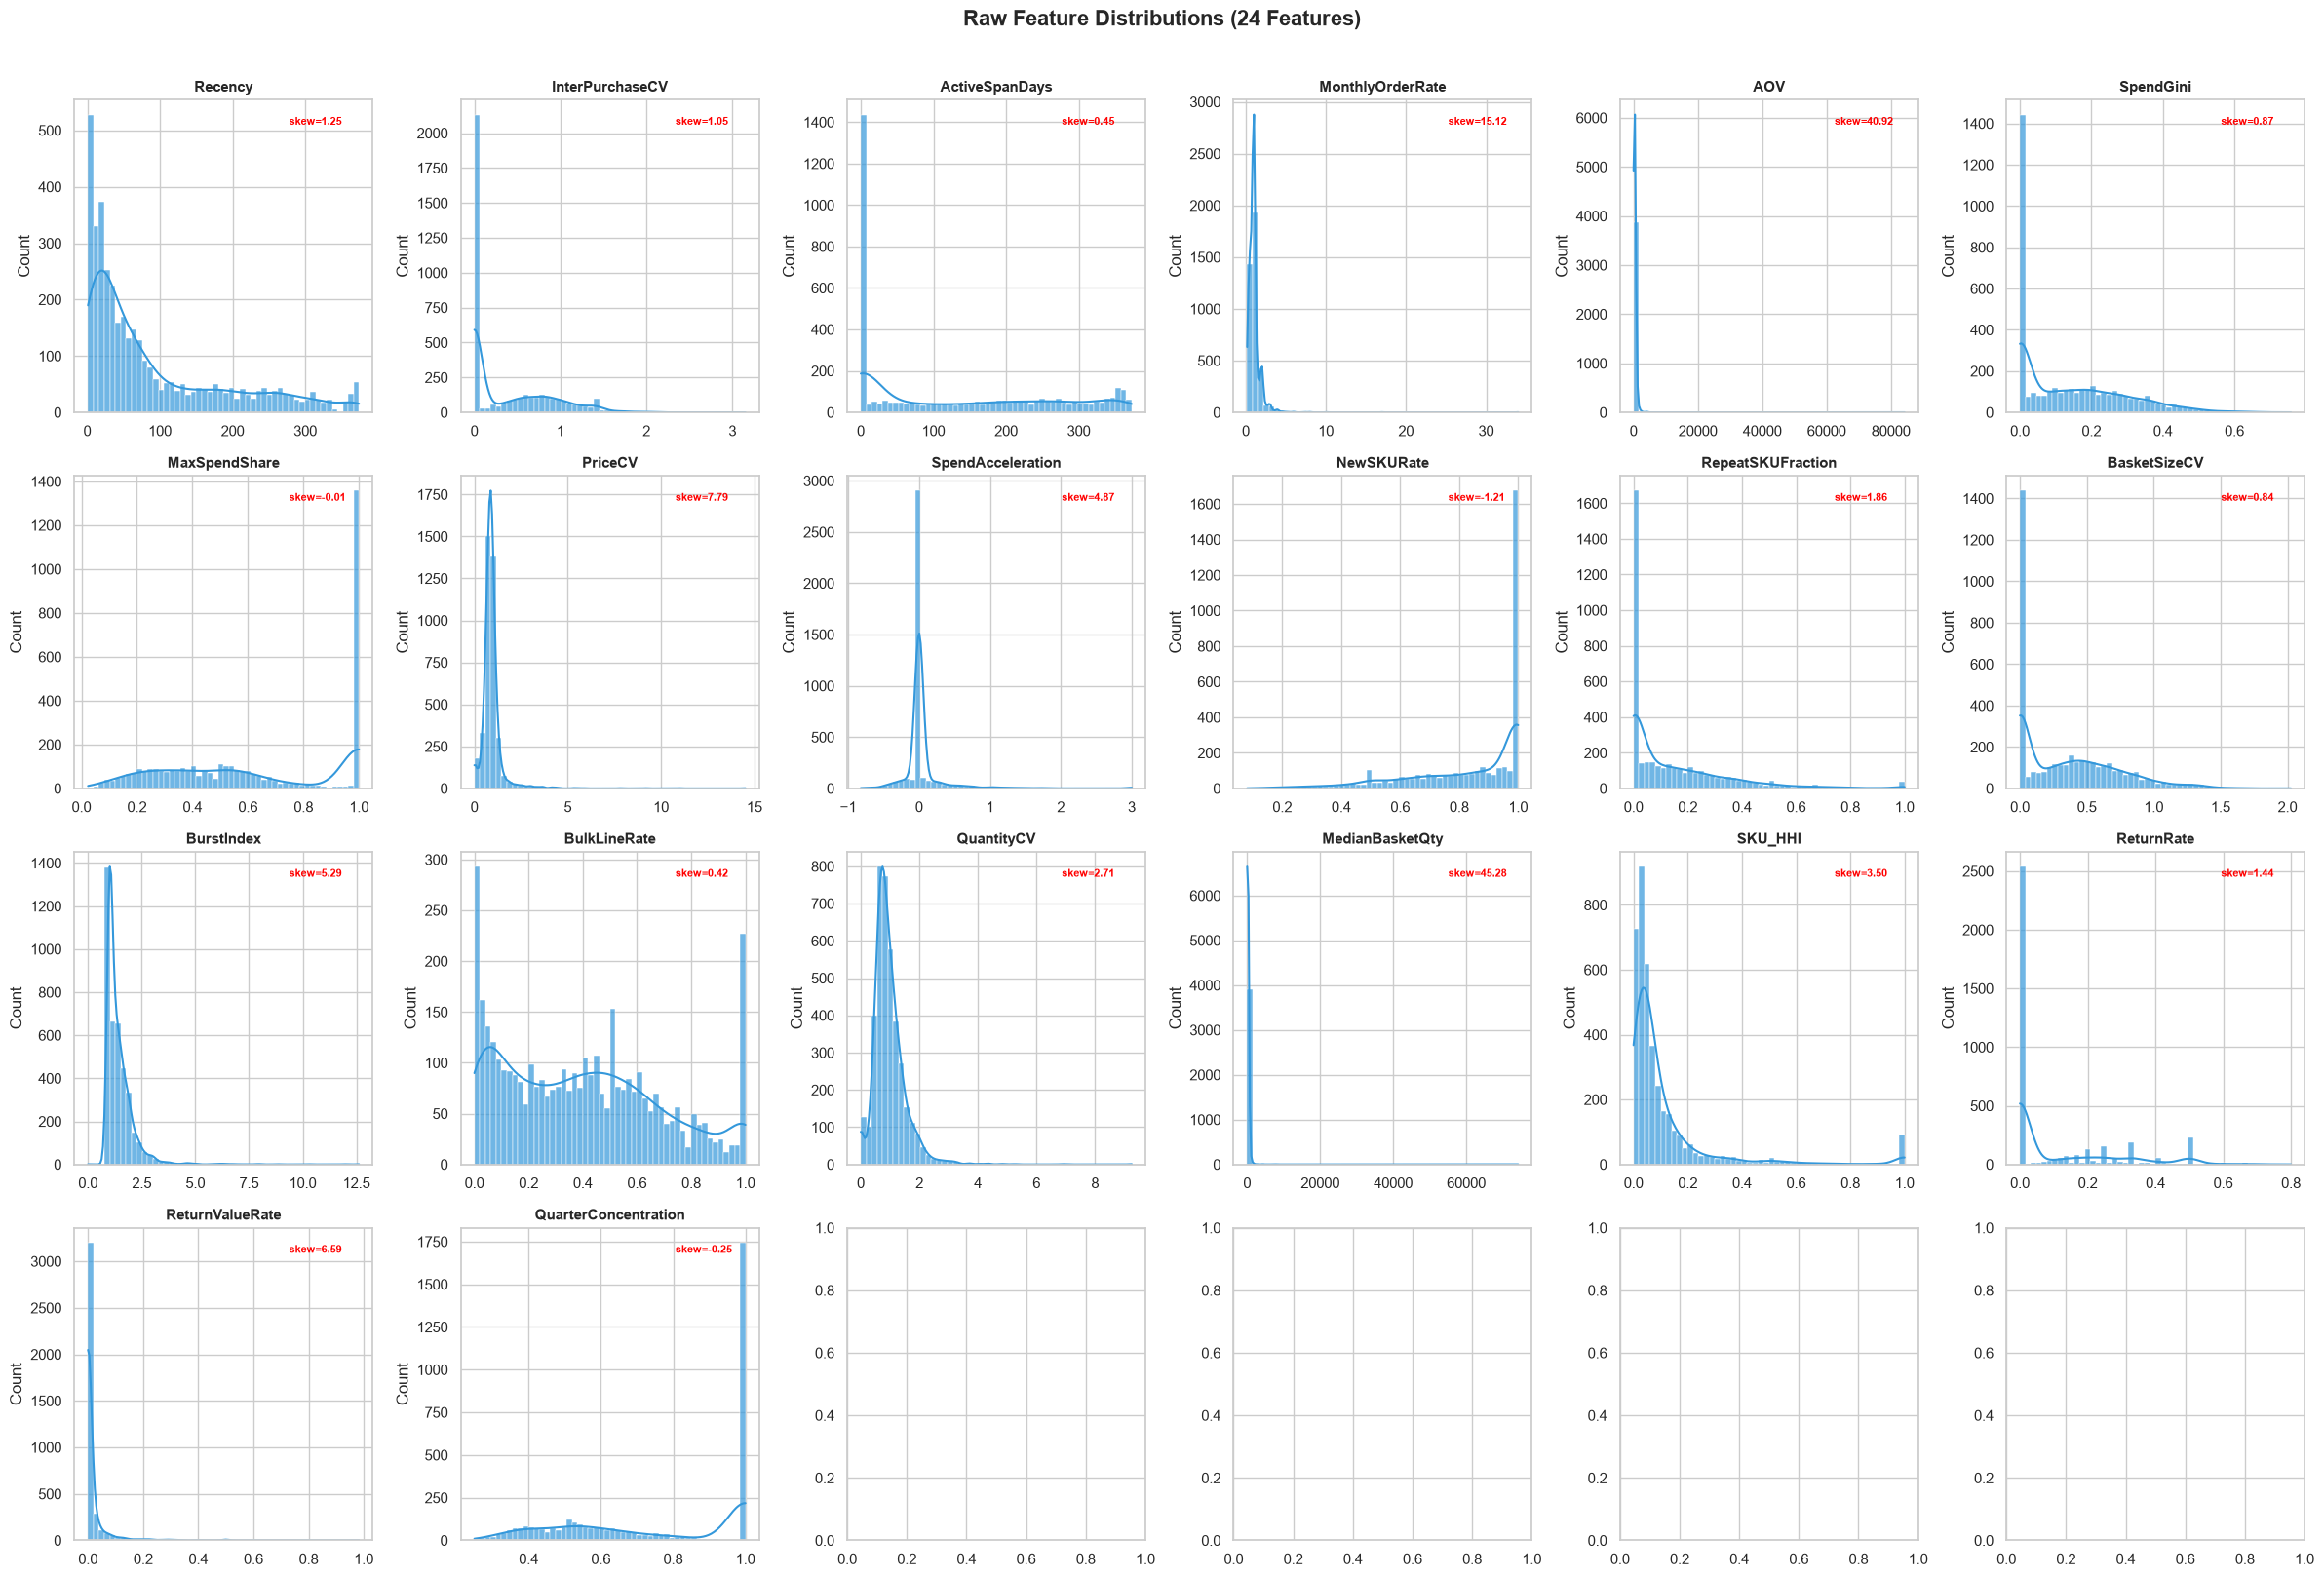

In [37]:
# Descriptive stats
print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
display(features.describe().T[['mean', '50%', 'max']].round(4))

# Check for NaN / Inf
nan_count = features.isna().sum().sum()
inf_count = np.isinf(features.values).sum()
print(f"\nNaN values: {nan_count}")
print(f"Inf values: {inf_count}")
assert nan_count == 0, "NaN values found!"
assert inf_count == 0, "Inf values found!"
print("No NaN or Inf values")

# Histogram grid (4×5) of raw feature distributions
fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

for i, col in enumerate(features.columns):
    ax = axes[i]
    sns.histplot(features[col], kde=True, ax=ax, bins=50,
                 color='#3498db', edgecolor='white', alpha=0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    # Add skewness annotation
    skew_val = features[col].skew()
    ax.annotate(f'skew={skew_val:.2f}', xy=(0.72, 0.92), xycoords='axes fraction',
                fontsize=8, color='red', fontweight='bold')

plt.suptitle('Raw Feature Distributions (24 Features)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

K-Means clustering relies on Euclidean distance, making it highly sensitive to data shape, scale, and multicollinearity. This pipeline ensures the data is optimally transformed into a stable "Model Space" before clustering.

### 1. Dual Scaling & Outlier Capping (`to_model_space`)
* **`QuantileTransformer(output_distribution='normal')`**: A rank-based transformation that forces all features (regardless of original skewness or outliers) into a normal distribution. This prevents centroid dragging caused by skewed data.
* **`StandardScaler()`**: Applied immediately after to ensure all features strictly share a mean of $0$ and a standard deviation of $1$, guaranteeing equal weight computation in K-Means.
* **3-Sigma Clipping (`np.clip`)**: Caps extreme values at $[-3.0, 3.0]$. This handles the remaining $0.27\%$ of extreme outliers, preventing solitary data points from forming meaningless micro-clusters.

### 2. Greedy Correlation Filter
Retaining highly correlated features (e.g., $> 0.85$) causes K-Means to double-count specific behaviors. This heuristic algorithm resolves multicollinearity:
* Uses **Spearman correlation** (rank-based) to align with the Quantile-transformed data.
* **Iterative dropping:** In each loop, it identifies highly correlated pairs and drops exactly *one* feature—the one with the highest mean correlation to the rest of the dataset (the most redundant feature).
* **Protected Features:** Designated core business metrics (`FORCE_KEEP`) are shielded from deletion to preserve fundamental business logic across all domains.

### 3. Family Weight Ratio (Implicit Weight Balancing)
* **The Problem:** If the "Spend Shape" family retains 4 features while "Lifecycle" retains 1, K-Means will implicitly weigh Spend Shape 4x heavier in distance calculations.
* **The Solution:** Each surviving feature is multiplied by a penalty weight of $\frac{1}{\sqrt{N}}$ (where $N$ is the number of surviving features in its family). Since K-Means squares distances ($d^2 = \sum x^2$), this ensures the total mathematical influence of each business family is exactly equal to $1$.

In [38]:
print(FORCE_KEEP)

def to_model_space(X, n_q=500):
    qt = QuantileTransformer(output_distribution='normal',
                             n_quantiles=min(n_q, len(X)), random_state=SEED)
    z = StandardScaler().fit_transform(qt.fit_transform(X))
    return pd.DataFrame(np.clip(z, -3.0, 3.0), columns=X.columns, index=X.index)


def filter_by_correlation(X, threshold=0.85, protected=()):
    cols, protected = list(X.columns), set(protected)
    while True:
        corr = X[cols].corr().abs().to_numpy().copy()   
        np.fill_diagonal(corr, 0.0)
        droppable = [c for c, v in zip(cols, (corr > threshold).any(axis=1))
                     if v and c not in protected]
        if not droppable:
            return cols
        mean_corr = pd.Series(corr.mean(axis=0), index=cols)
        cols.remove(mean_corr[droppable].idxmax())

kept    = filter_by_correlation(to_model_space(features), 0.85, FORCE_KEEP)
dropped = [c for c in features if c not in kept]

f2f = {f: fam for fam, fs in FAMILIES.items() for f in fs if f in features.columns}
n_fam = pd.Series([f2f[f] for f in kept]).value_counts()
weights = pd.Series({f: 1 / np.sqrt(n_fam[f2f[f]]) for f in kept})
scaled = to_model_space(features[kept]).mul(weights, axis=1)

# In báo cáo kết quả
print(f"Keep : {len(kept)} features")
print(f"Eliminated : {dropped}")
print(f"Range of features after transformation and filtering: [{scaled.values.min():.2f}, {scaled.values.max():.2f}]")
print("-" * 50)
print(pd.DataFrame({
    'Family': [f2f[f] for f in kept],
    ' K-Means Weights': weights[kept].round(4).values
}, index=kept).to_string())


['Recency', 'MonthlyOrderRate', 'ReturnRate', 'QuarterConcentration', 'SKU_HHI']
Keep : 15 features
Eliminated : ['ActiveSpanDays', 'SpendGini', 'MaxSpendShare', 'NewSKURate', 'ReturnValueRate']
Range of features after transformation and filtering: [-1.73, 1.93]
--------------------------------------------------
                                  Family   K-Means Weights
Recency                  Purchase Rhythm            0.5774
InterPurchaseCV          Purchase Rhythm            0.5774
MonthlyOrderRate         Purchase Rhythm            0.5774
AOV                       Spending Shape            0.5774
PriceCV                   Spending Shape            0.5774
SpendAcceleration         Spending Shape            0.5774
RepeatSKUFraction       Basket Behaviour            0.7071
BasketSizeCV            Basket Behaviour            0.7071
BurstIndex                 Volume & Bulk            0.4472
BulkLineRate               Volume & Bulk            0.4472
QuantityCV                 Volume & B

In [39]:
scaled

,Recency,InterPurchaseCV,MonthlyOrderRate,AOV,PriceCV,SpendAcceleration,RepeatSKUFraction,BasketSizeCV,BurstIndex,BulkLineRate,QuantityCV,MedianBasketQty,SKU_HHI,ReturnRate,QuarterConcentration
CustomerID,,,,,,,,,,,,,,,
12346.0,0.878030,-0.530797,0.136905,1.732051,-1.732051,-0.030672,-0.821926,-0.923413,-0.484830,1.228815,-1.341641,1.341641,1.341641,1.119066,0.781205
12747.0,-0.847245,0.522924,-0.162375,0.321306,-0.180237,0.712758,0.760046,0.399424,0.402288,0.070002,-0.035362,-0.166650,0.329235,-0.518883,-0.627094
12748.0,-1.732051,1.010394,1.732051,-0.460584,1.364617,1.587082,0.830058,0.854253,1.341641,-0.179675,0.936761,-0.594901,-1.106126,0.800848,-0.582759
12749.0,-0.652088,0.661847,-0.287920,0.946316,0.214521,-0.757050,0.579718,0.627498,0.700536,-0.071514,0.180379,0.245163,-0.680549,1.015283,-0.672002
12820.0,-0.740167,0.718018,-0.773805,-0.125957,-0.297770,0.681586,0.429916,0.398035,0.177401,0.137754,-0.209005,0.112149,-0.321514,-0.518883,-0.542702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18280.0,0.698810,-0.530797,0.136905,-0.356248,-0.555442,-0.030672,-0.821926,-0.923413,-0.484830,-1.232767,-0.475213,-0.570827,0.209588,-0.518883,0.781205
18281.0,0.429659,-0.530797,0.136905,-0.994487,0.727755,-0.030672,-0.821926,-0.923413,-0.484830,0.032631,-0.196464,-0.502995,0.370841,-0.518883,0.781205
18282.0,-0.513015,-0.530797,-0.521869,-0.945876,0.195133,-0.030672,-0.821926,0.349627,-0.110449,-0.136047,0.442146,-0.519703,0.191484,0.976352,-0.563254


In [ ]:
# Filter: SKU_HHI > 0.5 → B2B cohort

b2b_mask = features['SKU_HHI'] > B2B_THRESHOLD
df_b2b = features[b2b_mask].copy()
df_retail = features[~b2b_mask].copy()

print(f"B2B customers (SKU_HHI > {B2B_THRESHOLD}): {len(df_b2b):,}")
print(f"Retail customers: {len(df_retail):,}")
print(f"B2B share: {len(df_b2b) / len(features) * 100:.1f}%")

# Save B2B cohort
b2b_path = '../data/processed/b2b_customers.csv'
retail_customer_path='../data/processed/retail_customers.csv'
scaled_retail = scaled[~b2b_mask.values].copy()
scaled_retail.to_csv(retail_customer_path)
df_b2b.to_csv(b2b_path)


print(f"\n B2B customers saved to {b2b_path}")

# Continue with retail cohort only
print(f"\nRetail cohort shape for clustering: {df_retail.shape}")

B2B customers (SKU_HHI > 0.5): 179
Retail customers: 3,742
B2B share: 4.6%

 B2B customers saved to ../data/processed/b2b_customers.csv

Retail cohort shape for clustering: (3742, 20)
